In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import json
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

sns.set(style='whitegrid')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Load the JSON data
with open('/content/CETM47_24_5-AS2-Data.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (6443, 5)


,text,date,label,id,label_name
0,The {@Clinton LumberKings@} beat the {@Cedar R...,2019-09-08,4,1170516324419866624,sports_&_gaming
1,I would rather hear Eli Gold announce this Aub...,2019-09-08,4,1170516440690176006,sports_&_gaming
2,"Someone take my phone away, I’m trying to not ...",2019-09-08,4,1170516543387709440,sports_&_gaming
3,"A year ago, Louisville struggled to beat an FC...",2019-09-08,4,1170516620466429953,sports_&_gaming
4,Anyone know why the #Dodgers #Orioles game nex...,2019-09-08,4,1170516711411310592,sports_&_gaming


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset shape: (6443, 5)


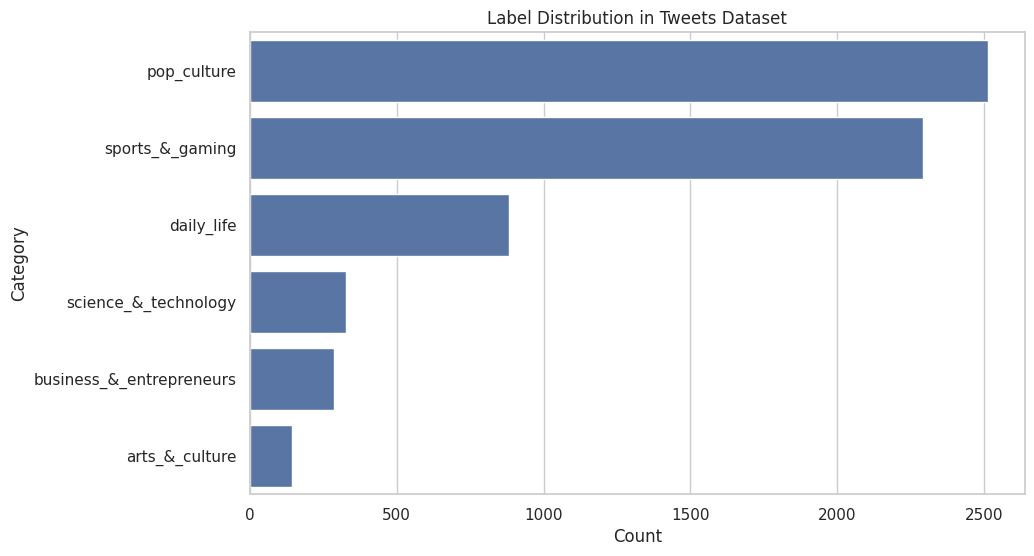

Number of unique categories: 6
label_name
pop_culture                 2512
sports_&_gaming             2291
daily_life                   883
science_&_technology         326
business_&_entrepreneurs     287
arts_&_culture               144
Name: count, dtype: int64
Filtered dataset shape: (6443, 5)


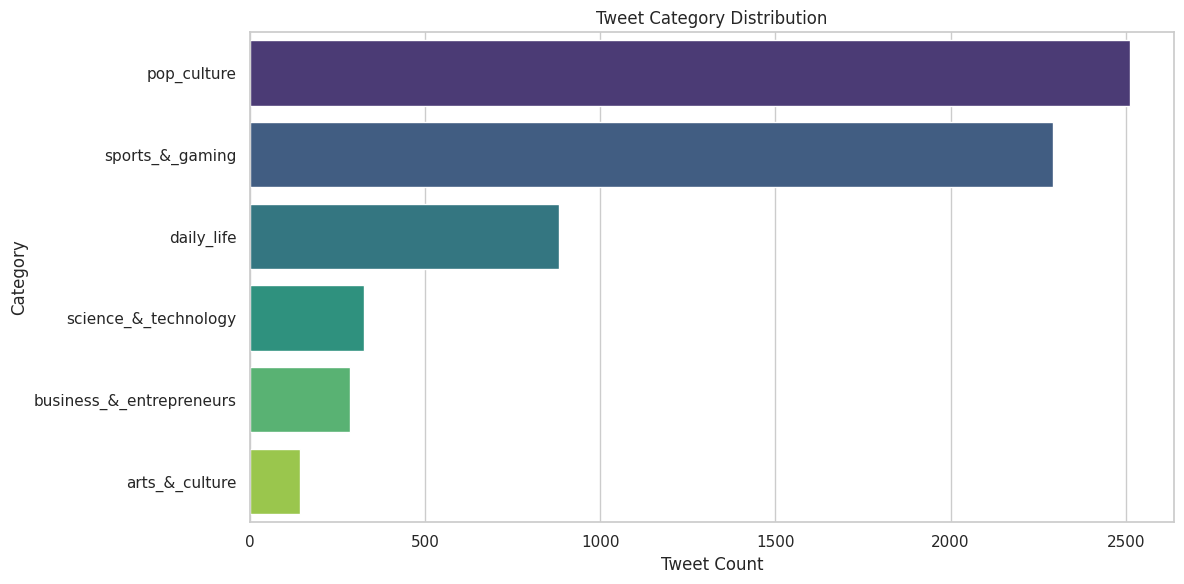

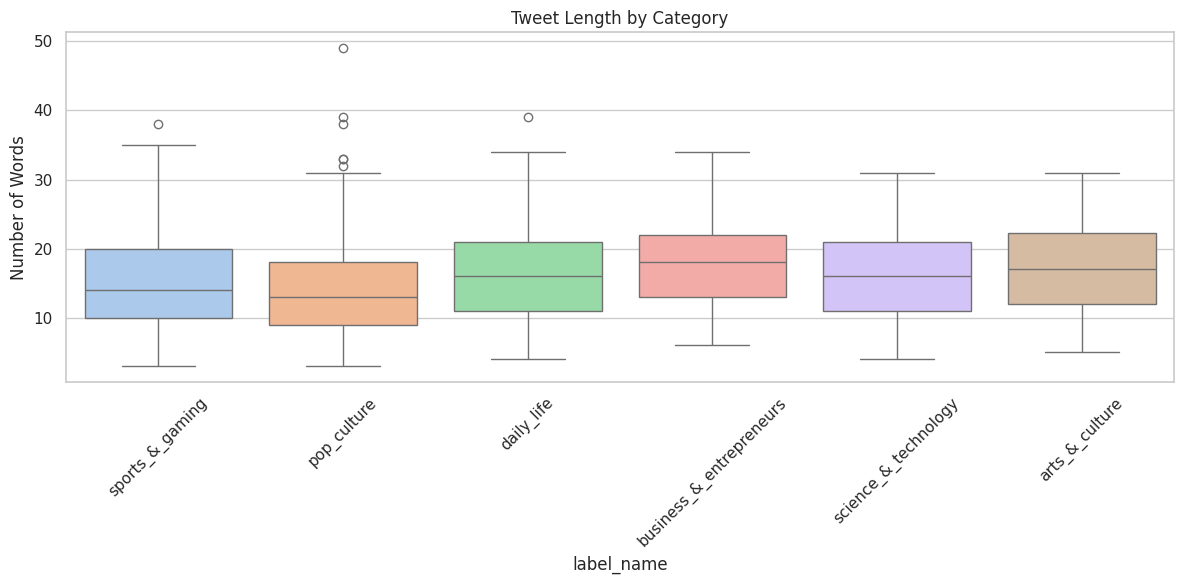

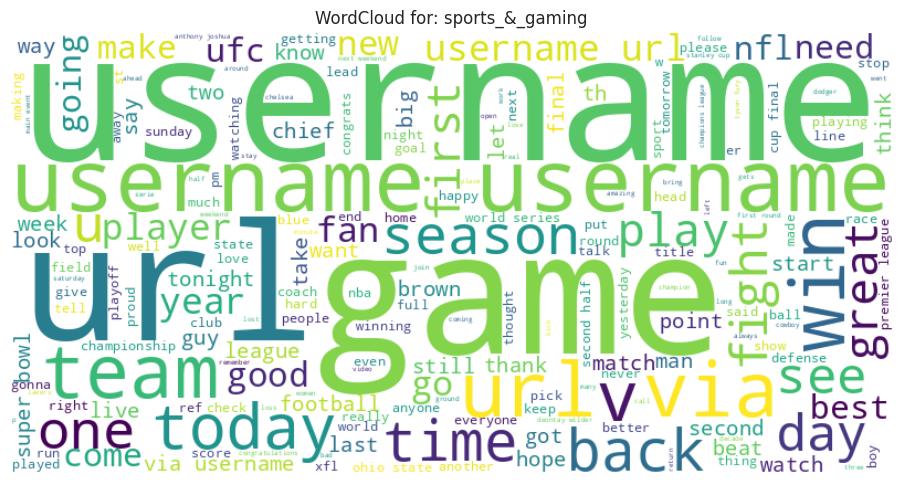

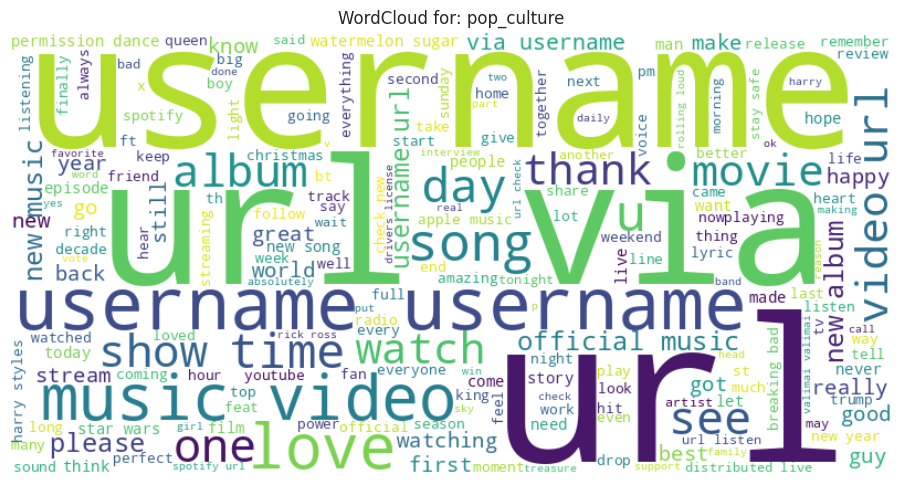

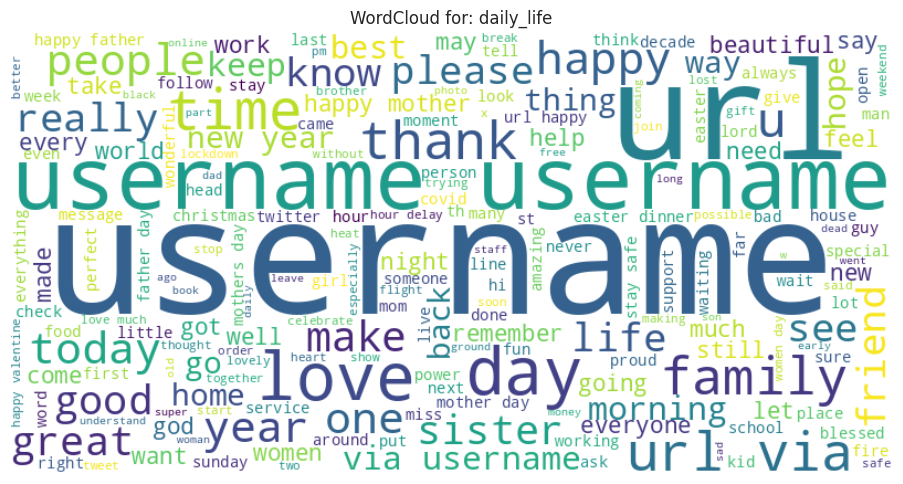

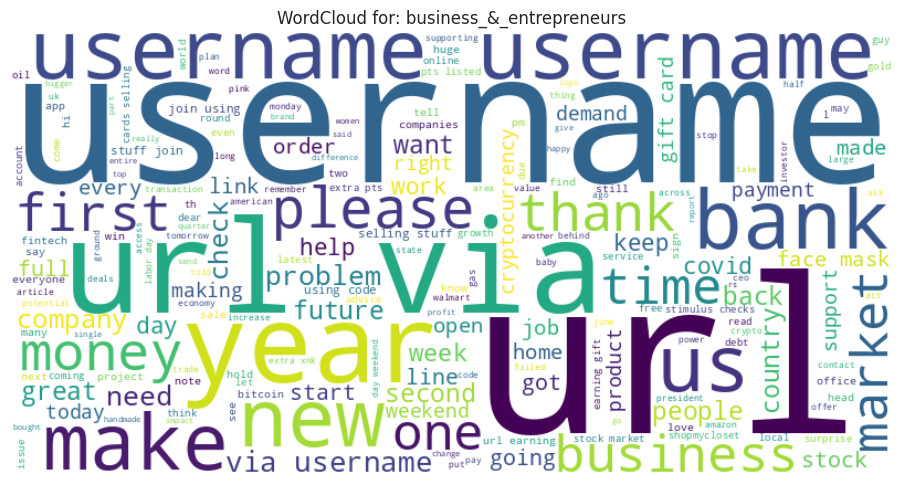

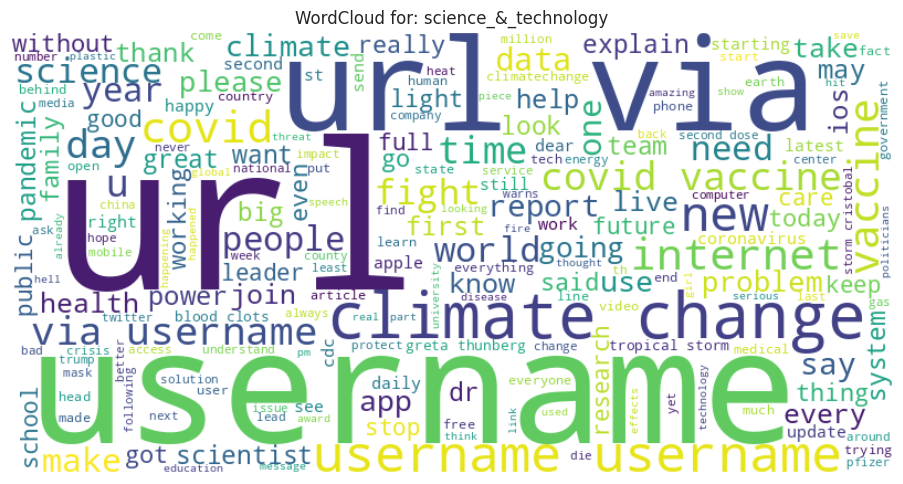

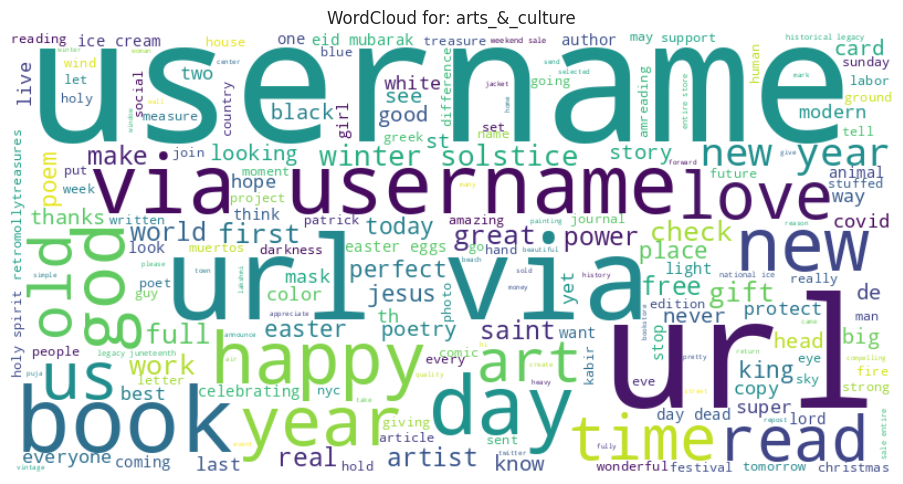

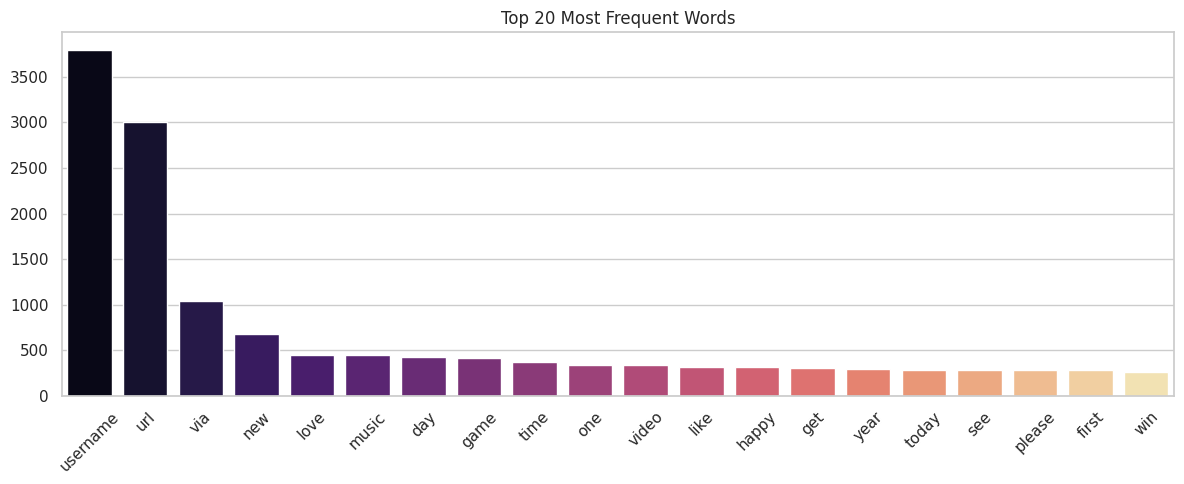

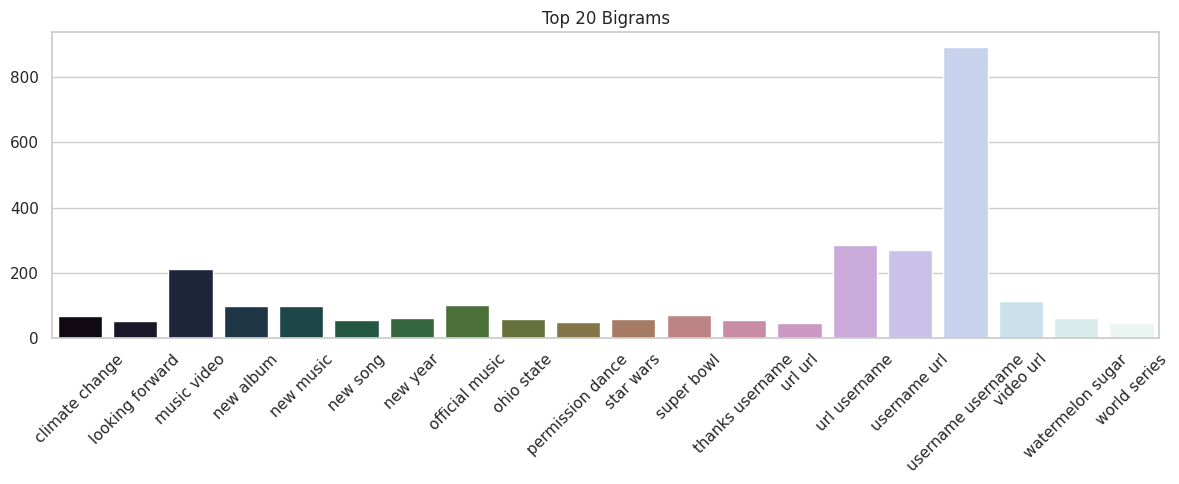

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import json
import warnings
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from wordcloud import WordCloud

warnings.filterwarnings('ignore')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

sns.set(style='whitegrid')

# Load the JSON data
with open('/content/CETM47_24_5-AS2-Data.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

# Class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='label_name', data=df, order=df['label_name'].value_counts().index)
plt.title("Label Distribution in Tweets Dataset")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

print("Number of unique categories:", df['label_name'].nunique())
print(df['label_name'].value_counts())

# Keep only top 10 categories by frequency
top_labels = df['label_name'].value_counts().nlargest(10).index
df_top10 = df[df['label_name'].isin(top_labels)].copy()
print("Filtered dataset shape:", df_top10.shape)

# Function to clean text
def clean_text(text):
    text = re.sub(r"{@.*?@}", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply clean_text function to create 'clean_text' column before other operations
df['clean_text'] = df['text'].apply(clean_text)  # Cleaning is performed on df

# Tweet Category Distribution
plt.figure(figsize=(12,6))
sns.countplot(y='label_name', data=df, order=df['label_name'].value_counts().index, palette='viridis')
plt.title("Tweet Category Distribution")
plt.xlabel("Tweet Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Recompute tweet length before plotting Tweet Length Distribution
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split())) # This line was moved here

# Tweet Length Distribution by Category
plt.figure(figsize=(12,6))
sns.boxplot(x='label_name', y='text_len', data=df, palette='pastel')
plt.title("Tweet Length by Category")
plt.xticks(rotation=45)
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

# WordCloud per Category
for label in df['label_name'].unique():
    text = " ".join(df[df['label_name'] == label]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for: {label}")
    plt.tight_layout()
    plt.show()

# Top 20 Words Overall
all_words = " ".join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)
words, counts = zip(*common_words)
plt.figure(figsize=(12,5))
sns.barplot(x=list(words), y=list(counts), palette='magma')
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 20 Bigrams
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X_bigrams = vectorizer.fit_transform(df['clean_text'])
bigrams = vectorizer.get_feature_names_out()
bigram_counts = X_bigrams.sum(axis=0).A1
plt.figure(figsize=(12,5))
sns.barplot(x=bigrams, y=bigram_counts, palette='cubehelix')
plt.title("Top 20 Bigrams")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

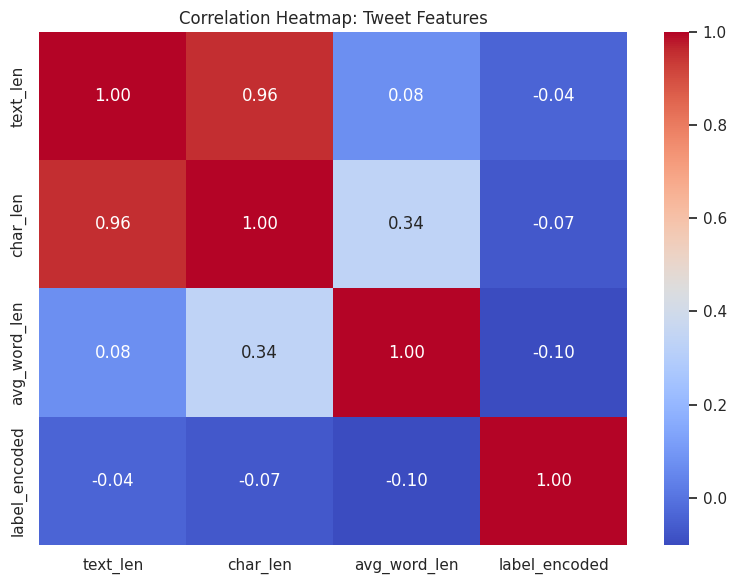

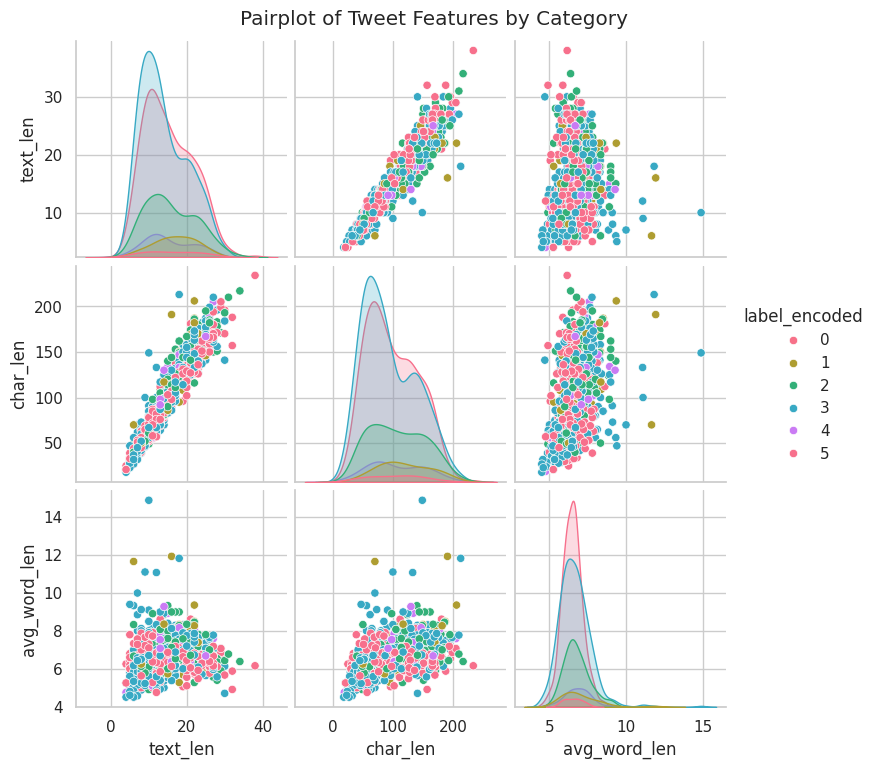

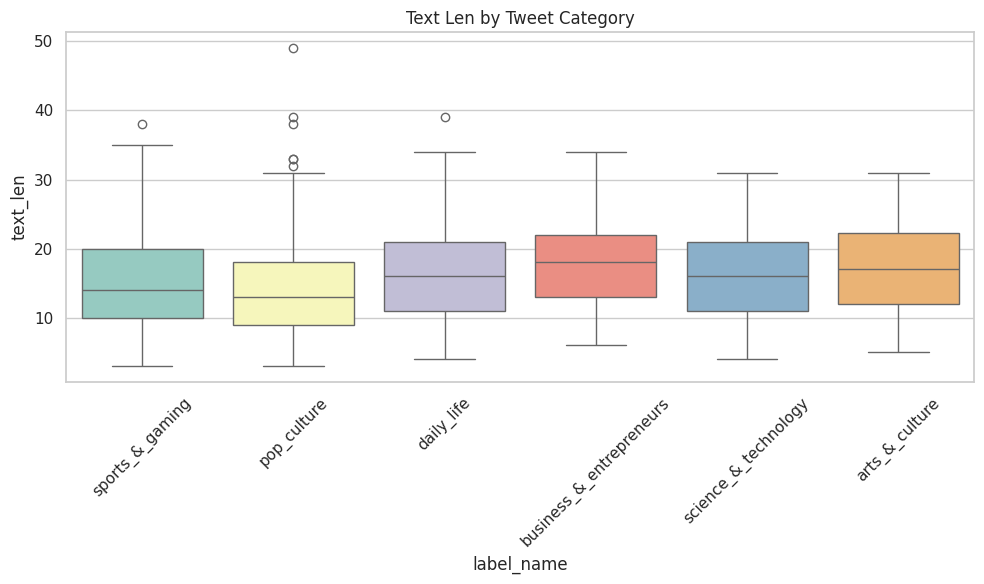

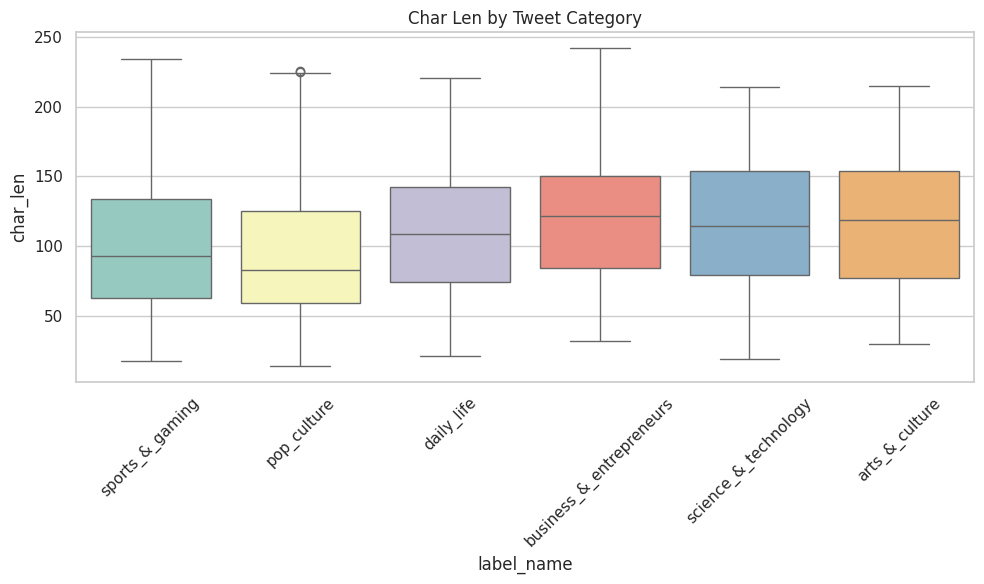

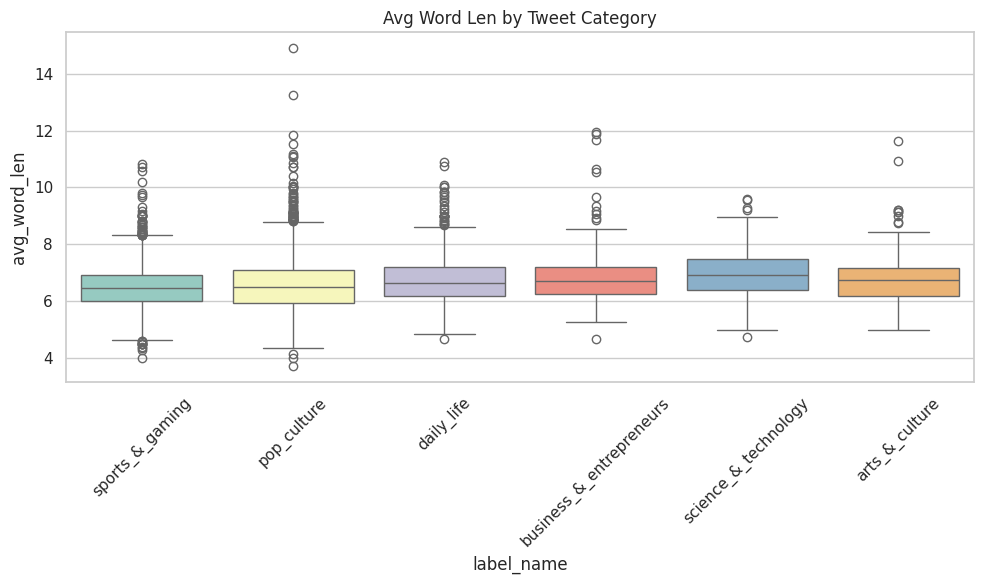

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Ensure clean_text and text_len columns exist
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_len'] = df['clean_text'].apply(len)
df['avg_word_len'] = df['char_len'] / df['text_len']

# Encode target class for numerical plotting
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label_name'])

# Select numerical features for correlation and pairplot
features = ['text_len', 'char_len', 'avg_word_len', 'label_encoded']
df_numeric = df[features].copy()

# 1. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap: Tweet Features")
plt.tight_layout()
plt.show()

# 2. Pairplot (downsample for performance)
df_sample = df_numeric.sample(n=1000, random_state=42)
sns.pairplot(df_sample, hue='label_encoded', palette='husl', diag_kind='kde')
plt.suptitle("Pairplot of Tweet Features by Category", y=1.02)
plt.show()

# 3. Box Plots for Each Feature
for col in ['text_len', 'char_len', 'avg_word_len']:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='label_name', y=col, data=df, palette='Set3')
    plt.title(f"{col.replace('_', ' ').title()} by Tweet Category")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [13]:
def clean_text(text):
    text = re.sub(r"{@.*?@}", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

df_top10['clean_text'] = df_top10['text'].apply(clean_text)
df_top10[['text', 'clean_text']].sample(5)


,text,clean_text
511,There is a time limit on how late I can do any...,time limit late anything requiring left brain ...
794,I would like to thank everyone at the Giants w...,would like thank everyone giants supported yea...
4032,Thread by {{USERNAME}} : Letter of Denial of R...,thread username letter denial request egypt ki...
1741,#np heartfelt ☞ We Always Will {{URL}} ️ Sa...,np heartfelt always url sandy mclelland userna...
2860,Worth watching at least the 1st 10mins if I wa...,worth watching least st mins minister love off...


In [14]:
X = df_top10['clean_text']
y = df_top10['label_name']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 5154
Test size: 1289


In [15]:
from sklearn.metrics import classification_report

pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', LogisticRegression(solver='liblinear', C=1.0))
    ]),
    'Support Vector Machine': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', LinearSVC(C=1.0))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', MultinomialNB(alpha=0.1))
    ])
}


In [16]:
for name, pipe in pipelines.items():
    print(f"\n=== {name} ===")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))



=== Logistic Regression ===
                          precision    recall  f1-score   support

          arts_&_culture       0.00      0.00      0.00        29
business_&_entrepreneurs       0.80      0.14      0.24        57
              daily_life       0.72      0.41      0.53       177
             pop_culture       0.73      0.89      0.80       503
    science_&_technology       0.75      0.28      0.40        65
         sports_&_gaming       0.78      0.92      0.84       458

                accuracy                           0.75      1289
               macro avg       0.63      0.44      0.47      1289
            weighted avg       0.73      0.75      0.72      1289


=== Support Vector Machine ===
                          precision    recall  f1-score   support

          arts_&_culture       0.44      0.14      0.21        29
business_&_entrepreneurs       0.53      0.44      0.48        57
              daily_life       0.61      0.58      0.59       177
           


📊 Confusion Matrix for LogisticRegression


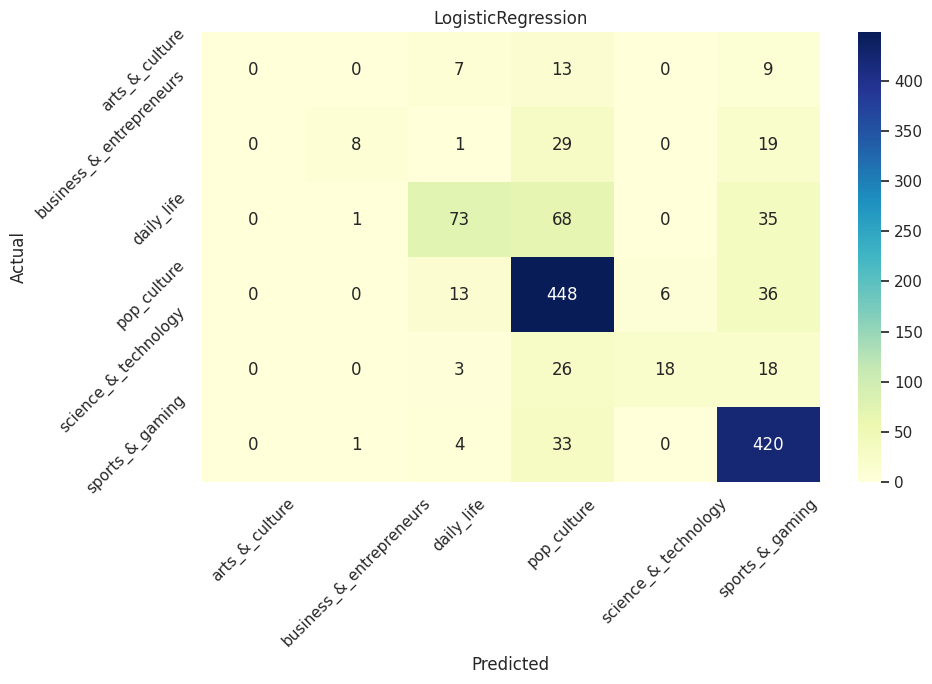


📊 Confusion Matrix for SVM


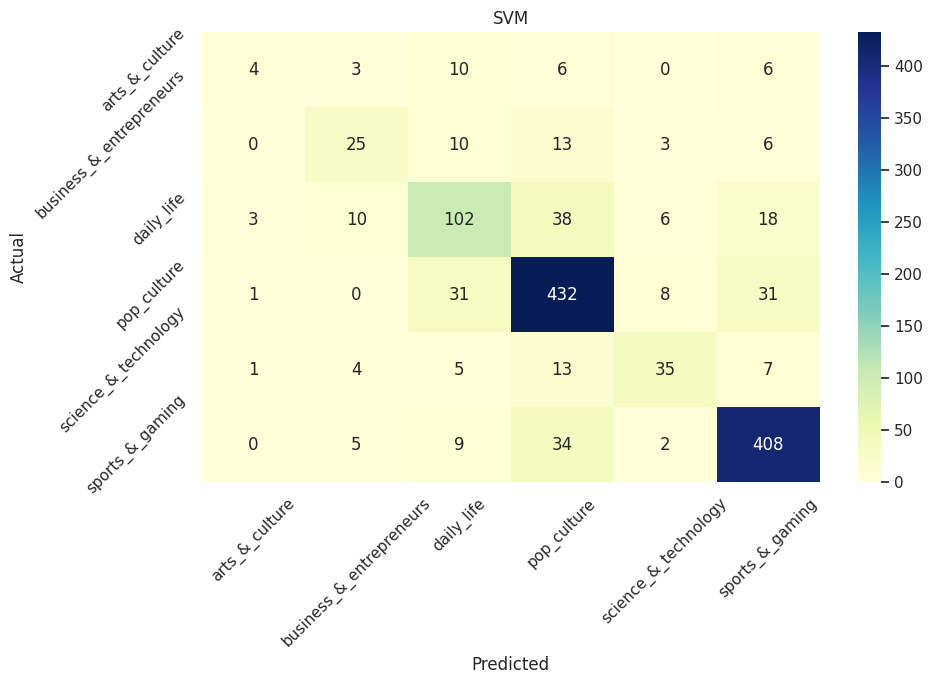


📊 Confusion Matrix for NaiveBayes


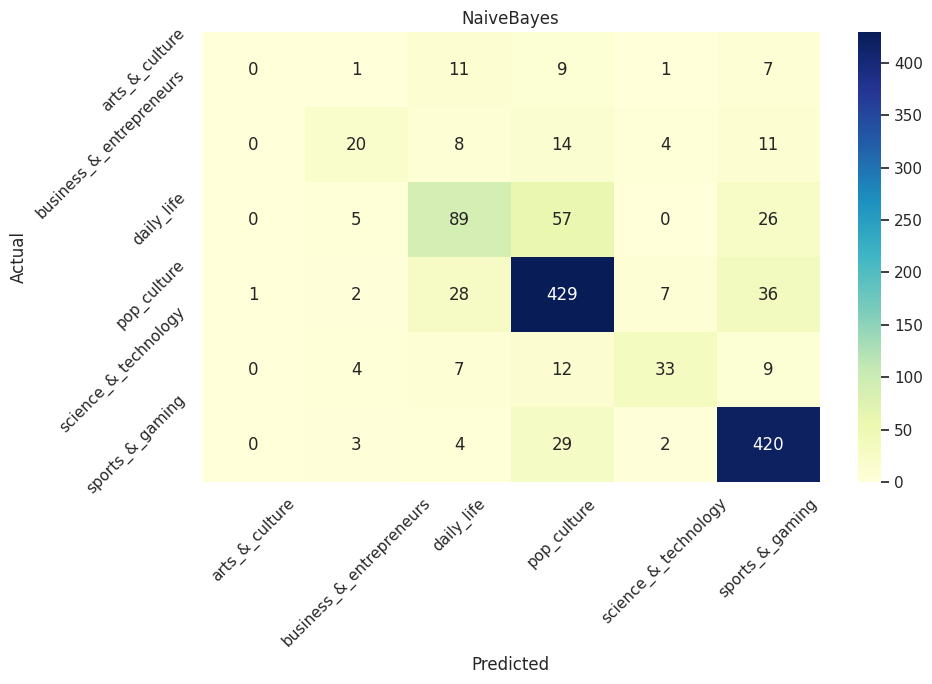

In [18]:
def plot_conf_matrix(cm, labels, title):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot for each model
for name, result in metrics_summary.items():
    print(f"\n📊 Confusion Matrix for {name}")
    plot_conf_matrix(result['conf_matrix'], labels=result['model'].classes_, title=name)


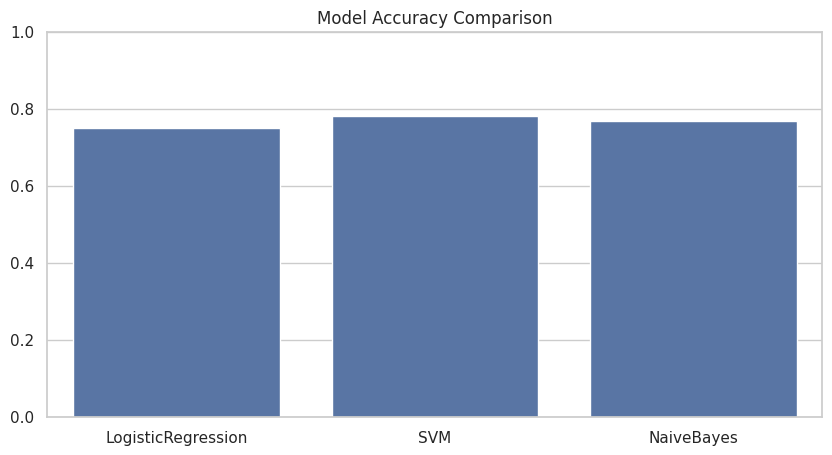

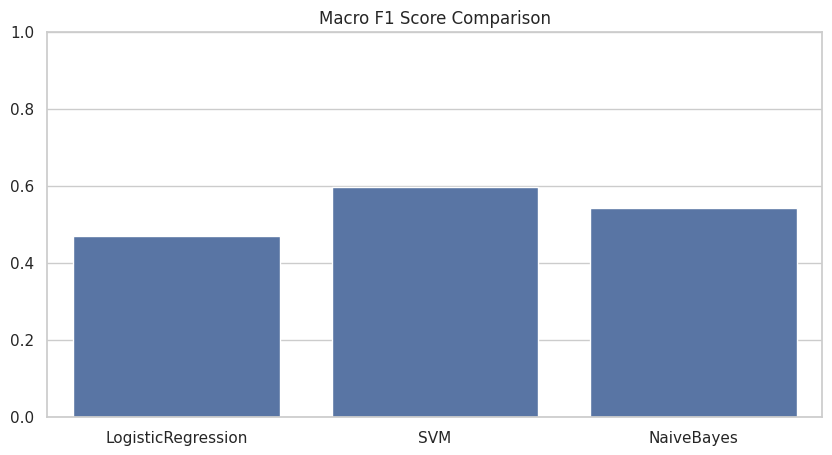

In [20]:
model_names = list(metrics_summary.keys())
accs = [metrics_summary[m]['accuracy'] for m in model_names]
f1s = [metrics_summary[m]['f1_score'] for m in model_names]

plt.figure(figsize=(10,5))
sns.barplot(x=model_names, y=accs)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=model_names, y=f1s)
plt.title("Macro F1 Score Comparison")
plt.ylim(0, 1)
plt.show()


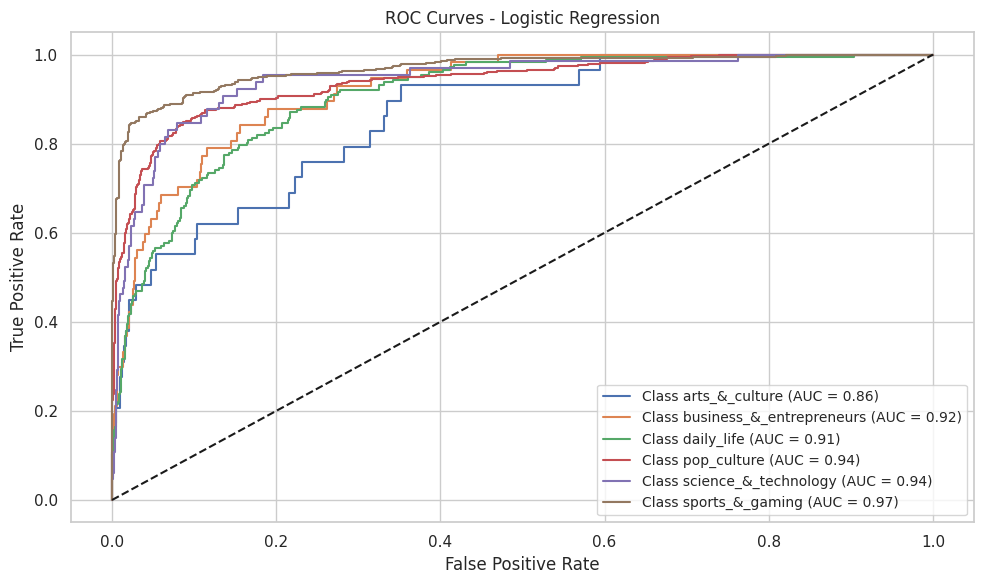

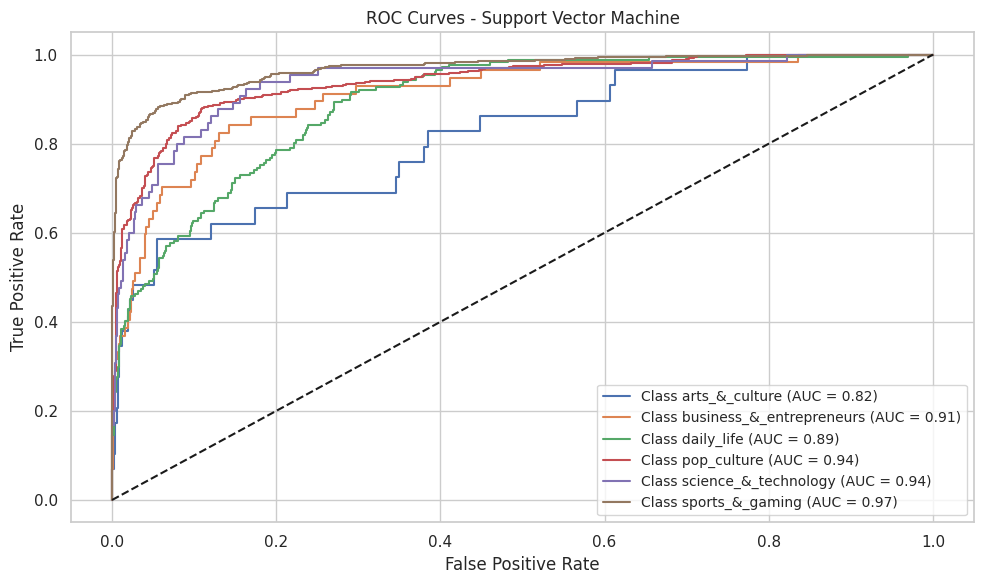

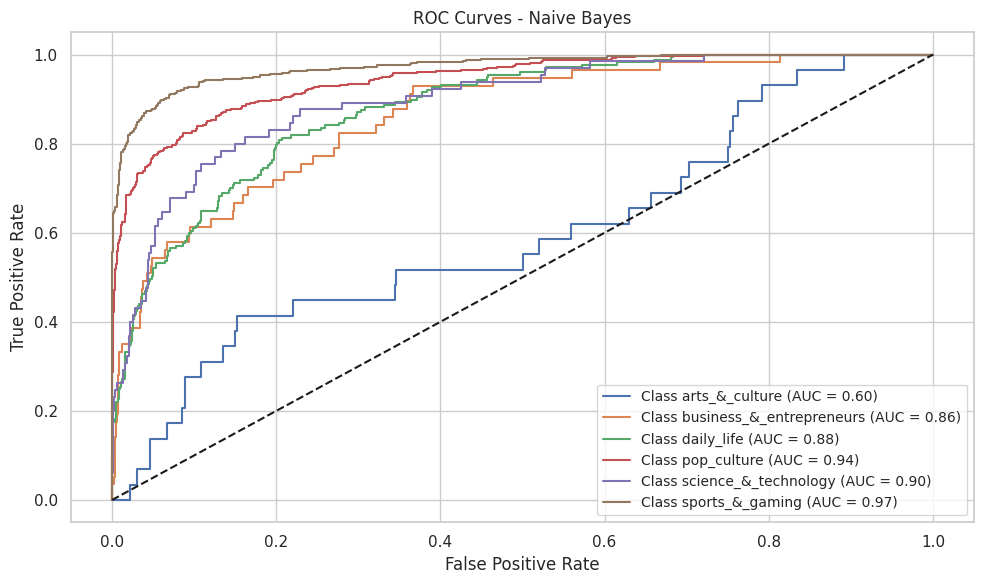

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Prepare data
X = df['clean_text']
y = df['label_name']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_binarized = label_binarize(y_encoded, classes=np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binarized, test_size=0.2, random_state=42, stratify=y_encoded
)

# 🛠 Classifier definitions
models = {
    "Logistic Regression": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', LogisticRegression(solver='liblinear'))
    ])),
    "Support Vector Machine": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', LinearSVC(C=1.0, dual=False))
    ])),
    "Naive Bayes": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', MultinomialNB())
    ]))
}

# Plot ROC Curves
for model_name, clf in models.items():
    clf.fit(X_train, y_train)
    try:
        y_score = clf.decision_function(X_test)
    except:
        y_score = clf.predict_proba(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = y_binarized.shape[1]

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {le.inverse_transform([i])[0]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curves - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize='small')
    plt.tight_layout()
    plt.show()


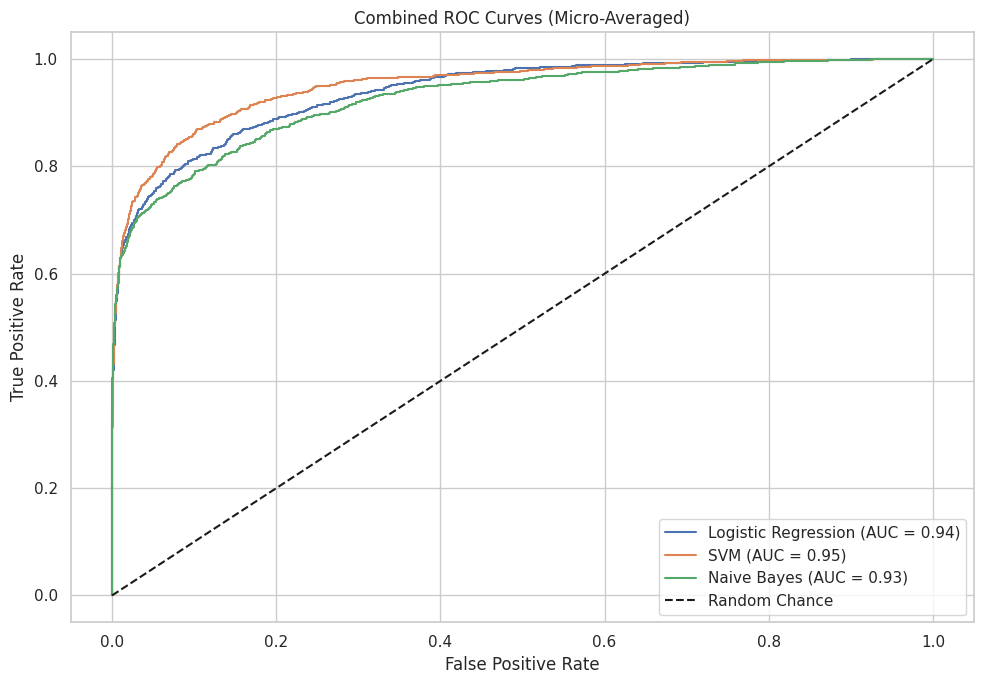

In [32]:
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['label_name'])
y_binarized = label_binarize(y_encoded, classes=np.unique(y_encoded))

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    df['clean_text'], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

y_train_bin = label_binarize(y_train_raw, classes=np.unique(y_encoded))
y_test_bin = label_binarize(y_test_raw, classes=np.unique(y_encoded))

# Define models
models = {
    "Logistic Regression": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', LogisticRegression(solver='liblinear'))
    ])),
    "SVM": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', LinearSVC(dual=False))
    ])),
    "Naive Bayes": OneVsRestClassifier(Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', MultinomialNB())
    ]))
}

# Initialize performance container
performance_table = []

# Combined ROC Plot
plt.figure(figsize=(10, 7))
for name, model in models.items():
    model.fit(X_train, y_train_bin)
    try:
        y_scores = model.decision_function(X_test)
    except:
        y_scores = model.predict_proba(X_test)

    # Compute ROC AUC for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    n_classes = y_test_bin.shape[1]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"], label=f'{name} (AUC = {roc_auc["micro"]:.2f})')

    # Calculate performance metrics
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_bin, y_pred)
    prec = precision_score(y_test_bin, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test_bin, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_bin, y_pred, average='macro', zero_division=0)

    performance_table.append({
        'Model': name,
        'Accuracy': acc,
        'Macro Precision': prec,
        'Macro Recall': rec,
        'Macro F1': f1
    })

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Combined ROC Curves (Micro-Averaged)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

